# 03 -- Matched/Weighted Outcome Analysis
Cox PH models on matched and IPTW samples. Compare HRs across unadjusted,
matched, and IPTW approaches. Test PH assumption. Subgroup forest plot.

**Inputs:** `data/processed/matched_cohort.csv`, `data/processed/iptw_cohort.csv`  
**Outputs:** KM curves, forest plot, PH diagnostics in `figures/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': '#0F0F14', 'axes.facecolor': '#0F0F14',
    'axes.edgecolor': '#2A2A35', 'axes.labelcolor': '#E2E0E6',
    'text.color': '#E2E0E6', 'xtick.color': '#9894A8',
    'ytick.color': '#9894A8', 'grid.color': '#1E1E28',
    'font.family': 'sans-serif', 'font.size': 11, 'figure.dpi': 150
})

PROCESSED = Path('../data/processed')
FIGURES = Path('../figures')

INDIGO = '#818CF8'; PINK = '#F472B6'; GREEN = '#10B981'; AMBER = '#F59E0B'

In [2]:
matched = pd.read_csv(PROCESSED / 'matched_cohort.csv')
full = pd.read_csv(PROCESSED / 'iptw_cohort.csv')
print(f'Matched: {matched.shape}')
print(f'Full (with IPTW): {full.shape}')

Matched: (6962, 21)
Full (with IPTW): (18129, 23)


---
## 1. Kaplan-Meier curves: unadjusted

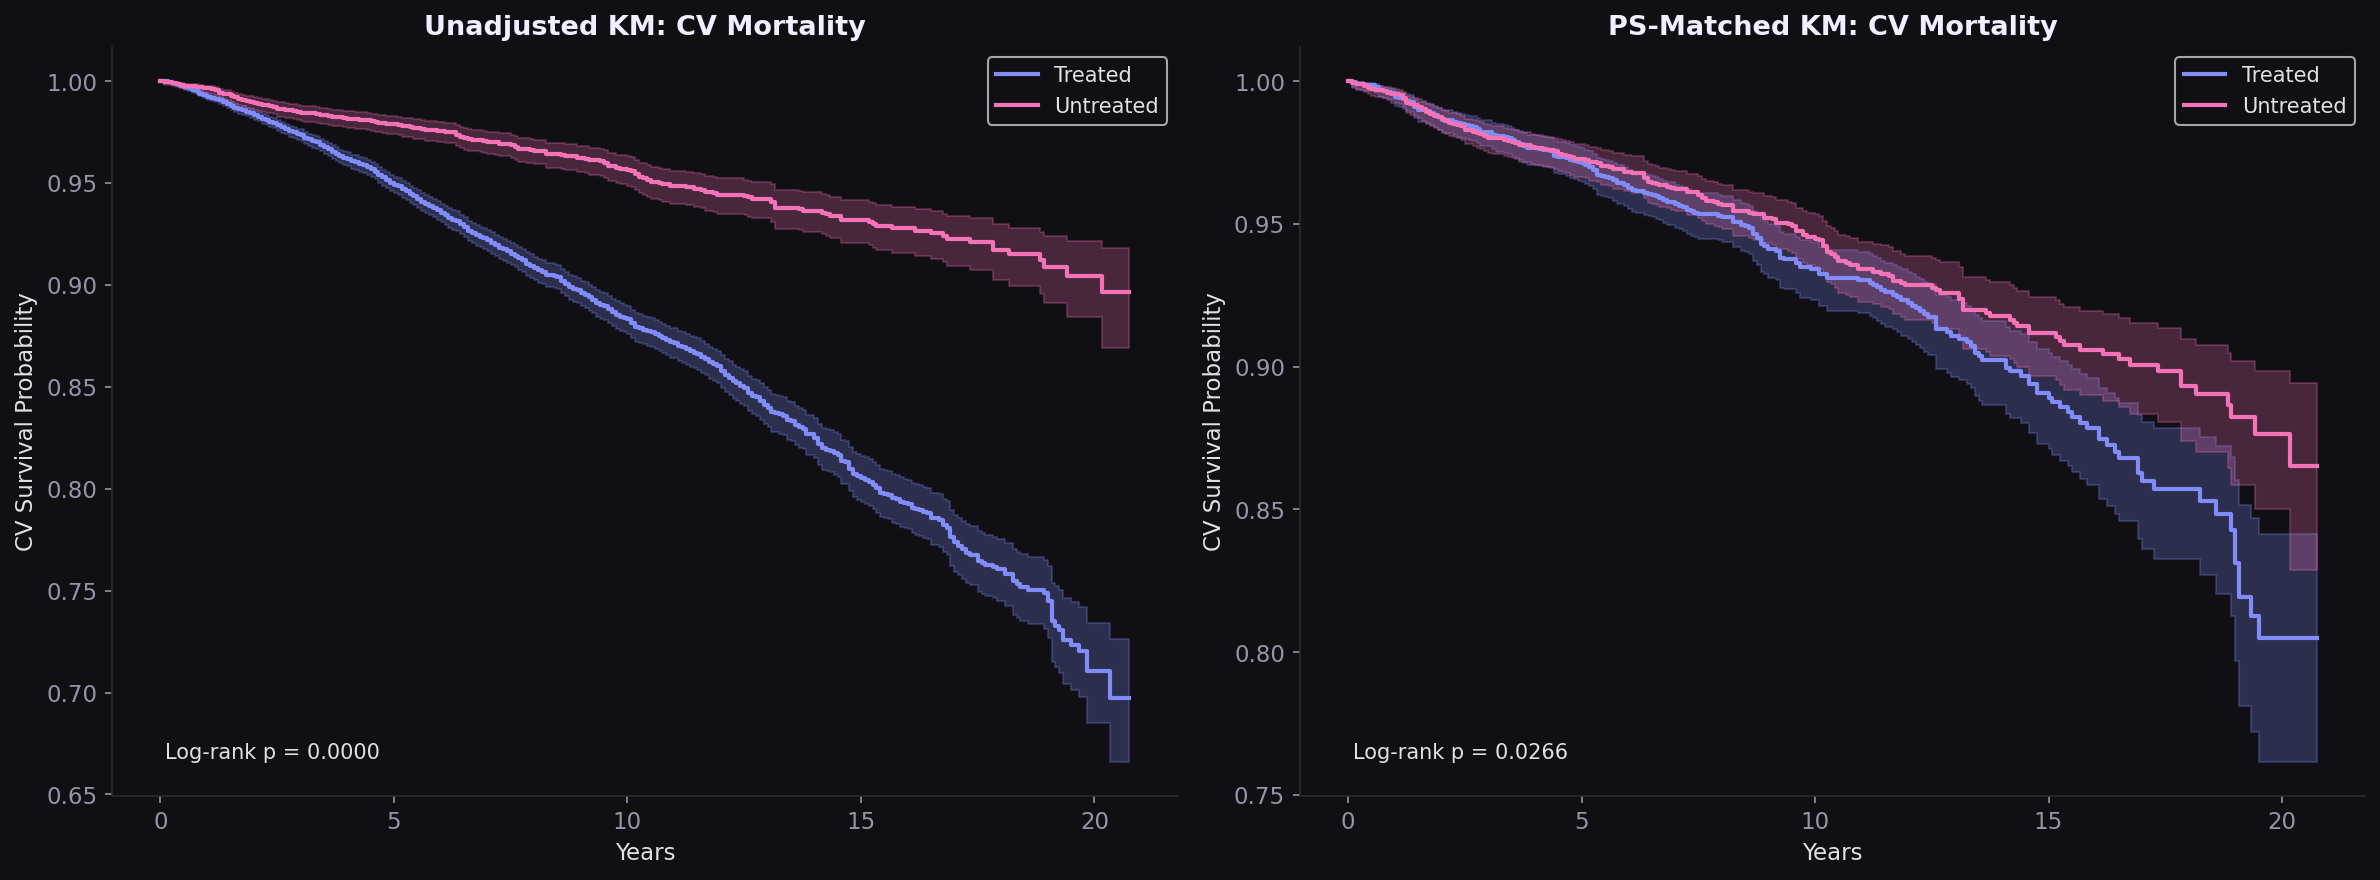

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Unadjusted (full cohort)
ax = axes[0]
kmf_t = KaplanMeierFitter()
kmf_c = KaplanMeierFitter()

t_data = full[full['treated'] == 1]
c_data = full[full['treated'] == 0]

kmf_t.fit(t_data['follow_up_yrs'], t_data['cv_death'], label='Treated')
kmf_c.fit(c_data['follow_up_yrs'], c_data['cv_death'], label='Untreated')

kmf_t.plot_survival_function(ax=ax, color=INDIGO, linewidth=2)
kmf_c.plot_survival_function(ax=ax, color=PINK, linewidth=2)

lr = logrank_test(t_data['follow_up_yrs'], c_data['follow_up_yrs'],
                  t_data['cv_death'], c_data['cv_death'])
ax.text(0.05, 0.05, f'Log-rank p = {lr.p_value:.4f}', transform=ax.transAxes,
        fontsize=10, color='#E2E0E6')
ax.set_title('Unadjusted KM: CV Mortality', fontsize=13, fontweight='bold', color='#F0EEFF')
ax.set_xlabel('Years')
ax.set_ylabel('CV Survival Probability')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# PS-Matched
ax = axes[1]
mt = matched[matched['treated'] == 1]
mc = matched[matched['treated'] == 0]

kmf_mt = KaplanMeierFitter()
kmf_mc = KaplanMeierFitter()
kmf_mt.fit(mt['follow_up_yrs'], mt['cv_death'], label='Treated')
kmf_mc.fit(mc['follow_up_yrs'], mc['cv_death'], label='Untreated')

kmf_mt.plot_survival_function(ax=ax, color=INDIGO, linewidth=2)
kmf_mc.plot_survival_function(ax=ax, color=PINK, linewidth=2)

lr_m = logrank_test(mt['follow_up_yrs'], mc['follow_up_yrs'], mt['cv_death'], mc['cv_death'])
ax.text(0.05, 0.05, f'Log-rank p = {lr_m.p_value:.4f}', transform=ax.transAxes,
        fontsize=10, color='#E2E0E6')
ax.set_title('PS-Matched KM: CV Mortality', fontsize=13, fontweight='bold', color='#F0EEFF')
ax.set_xlabel('Years')
ax.set_ylabel('CV Survival Probability')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES / 'km_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Cox PH models: unadjusted, matched, IPTW

In [4]:
results = []

# Model 1: Unadjusted
cph_unadj = CoxPHFitter()
cph_unadj.fit(full[['follow_up_yrs', 'cv_death', 'treated']],
              duration_col='follow_up_yrs', event_col='cv_death')
hr = np.exp(cph_unadj.params_['treated'])
ci = np.exp(cph_unadj.confidence_intervals_.loc['treated'])
p = cph_unadj.summary.loc['treated', 'p']
results.append({'Model': 'Unadjusted', 'HR': hr, 'CI_low': ci.iloc[0], 'CI_high': ci.iloc[1], 'p': p, 'N': len(full)})
print(f'Unadjusted: HR={hr:.3f} ({ci.iloc[0]:.3f}-{ci.iloc[1]:.3f}), p={p:.4f}')

# Model 2: PS-Matched
cph_matched = CoxPHFitter()
cph_matched.fit(matched[['follow_up_yrs', 'cv_death', 'treated']],
                duration_col='follow_up_yrs', event_col='cv_death')
hr = np.exp(cph_matched.params_['treated'])
ci = np.exp(cph_matched.confidence_intervals_.loc['treated'])
p = cph_matched.summary.loc['treated', 'p']
results.append({'Model': 'PS-Matched', 'HR': hr, 'CI_low': ci.iloc[0], 'CI_high': ci.iloc[1], 'p': p, 'N': len(matched)})
print(f'PS-Matched: HR={hr:.3f} ({ci.iloc[0]:.3f}-{ci.iloc[1]:.3f}), p={p:.4f}')

# Model 3: IPTW
cph_iptw = CoxPHFitter()
cph_iptw.fit(full[['follow_up_yrs', 'cv_death', 'treated', 'iptw_trimmed']],
             duration_col='follow_up_yrs', event_col='cv_death',
             weights_col='iptw_trimmed', robust=True)
hr = np.exp(cph_iptw.params_['treated'])
ci = np.exp(cph_iptw.confidence_intervals_.loc['treated'])
p = cph_iptw.summary.loc['treated', 'p']
results.append({'Model': 'IPTW', 'HR': hr, 'CI_low': ci.iloc[0], 'CI_high': ci.iloc[1], 'p': p, 'N': len(full)})
print(f'IPTW:       HR={hr:.3f} ({ci.iloc[0]:.3f}-{ci.iloc[1]:.3f}), p={p:.4f}')

# Model 4: IPTW + covariate adjusted (doubly robust)
adj_cols = ['follow_up_yrs', 'cv_death', 'treated', 'iptw_trimmed',
            'age', 'female', 'bmi', 'diabetes', 'smoker']
cph_dr = CoxPHFitter()
cph_dr.fit(full[adj_cols],
           duration_col='follow_up_yrs', event_col='cv_death',
           weights_col='iptw_trimmed', robust=True)
hr = np.exp(cph_dr.params_['treated'])
ci = np.exp(cph_dr.confidence_intervals_.loc['treated'])
p = cph_dr.summary.loc['treated', 'p']
results.append({'Model': 'Doubly Robust', 'HR': hr, 'CI_low': ci.iloc[0], 'CI_high': ci.iloc[1], 'p': p, 'N': len(full)})
print(f'Doubly Robust: HR={hr:.3f} ({ci.iloc[0]:.3f}-{ci.iloc[1]:.3f}), p={p:.4f}')

results_df = pd.DataFrame(results)
results_df

Unadjusted: HR=2.862 (2.468-3.318), p=0.0000
PS-Matched: HR=1.240 (1.025-1.501), p=0.0269


IPTW:       HR=1.021 (0.865-1.205), p=0.8076


Doubly Robust: HR=1.154 (0.977-1.362), p=0.0913


,Model,HR,CI_low,CI_high,p,N
0,Unadjusted,2.861943,2.468429,3.318190,4.010533e-44,18129
1,PS-Matched,1.240355,1.024964,1.501009,2.687473e-02,6962
2,IPTW,1.020854,0.864588,1.205365,8.076297e-01,18129
3,Doubly Robust,1.153689,0.977288,1.361931,9.129372e-02,18129


---
## 3. Forest plot: HR comparison across models

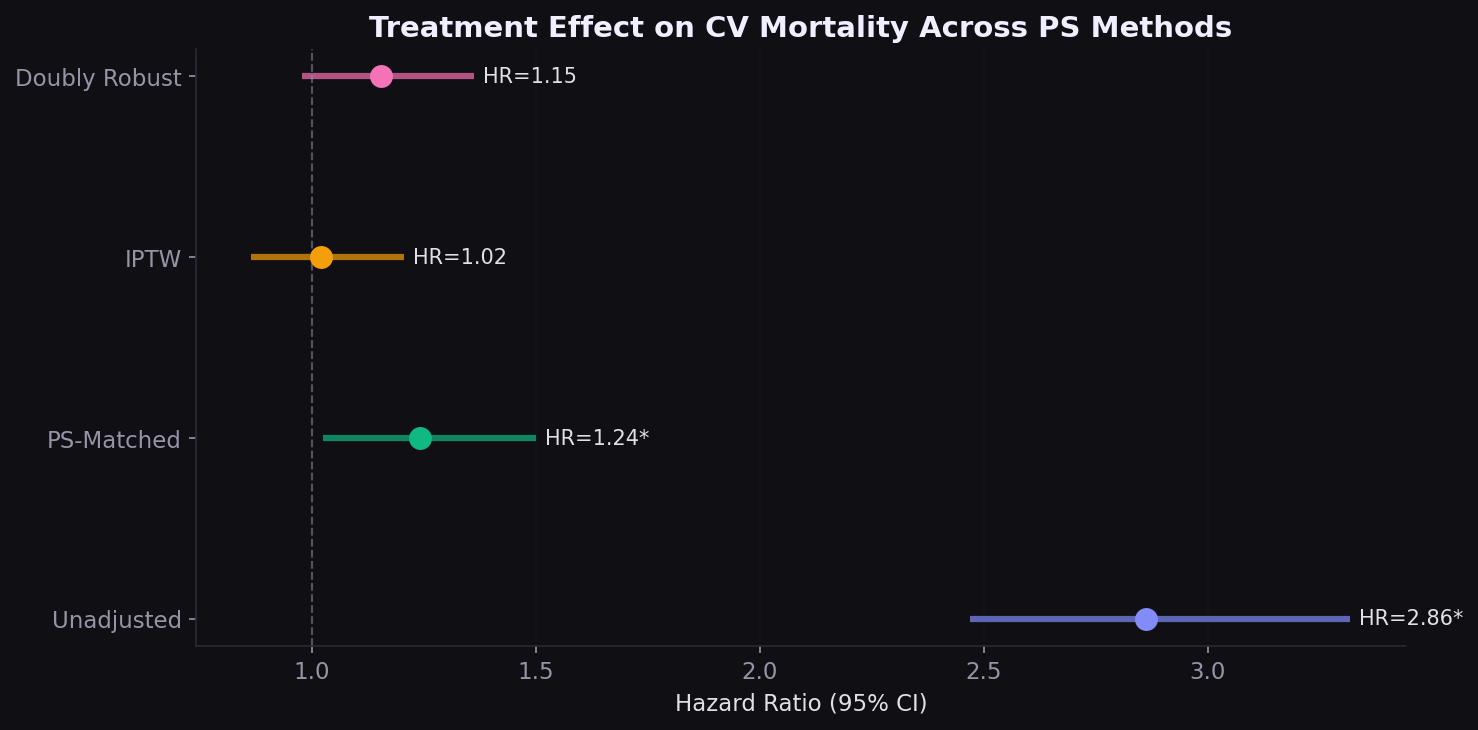

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(results_df))
colors = [INDIGO, GREEN, AMBER, PINK]

for i, (_, row) in enumerate(results_df.iterrows()):
    ax.scatter(row['HR'], i, color=colors[i], s=100, zorder=3)
    ax.hlines(i, row['CI_low'], row['CI_high'], color=colors[i], linewidth=3, alpha=0.7)
    sig = '*' if row['p'] < 0.05 else ''
    ax.text(row['CI_high'] + 0.02, i, f"HR={row['HR']:.2f}{sig}", va='center', fontsize=10, color='#E2E0E6')

ax.axvline(x=1, color='#9894A8', linestyle='--', alpha=0.5, linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(results_df['Model'], fontsize=11)
ax.set_xlabel('Hazard Ratio (95% CI)')
ax.set_title('Treatment Effect on CV Mortality Across PS Methods',
             fontsize=14, fontweight='bold', color='#F0EEFF')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'hr_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Proportional hazards assumption test

In [6]:
# Test PH assumption on matched Cox model
cph_ph = CoxPHFitter()
cph_ph.fit(matched[['follow_up_yrs', 'cv_death', 'treated', 'age', 'female', 'diabetes', 'smoker']],
           duration_col='follow_up_yrs', event_col='cv_death')

ph_test = cph_ph.check_assumptions(matched[['follow_up_yrs', 'cv_death', 'treated', 'age', 'female', 'diabetes', 'smoker']],
                                    p_value_threshold=0.05, show_plots=False)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 6962 total observations, 6536 right-censored observations>
         test_name = proportional_hazard_test

---
               test_statistic    p  -log2(p)
age      km              0.75 0.39      1.37
         rank            0.56 0.46      1.13
diabetes km              0.99 0.32      1.64
         rank            0.92 0.34      1.56
female   km              0.69 0.41      1.30
         rank            0.69 0.41      1.30
smoker   km              0.12 0.73      0.45
         rank            0.18 0.67      0.58
treated  km              4.43 0.04      4.82
         rank            3.18 0.07      3.75



1. Variable 'treated' failed the non-proportional test: p-value is 0.0354.

   Advice: with so few unique values (only 2), you can include `strata=['treated', ...]` in the call
in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



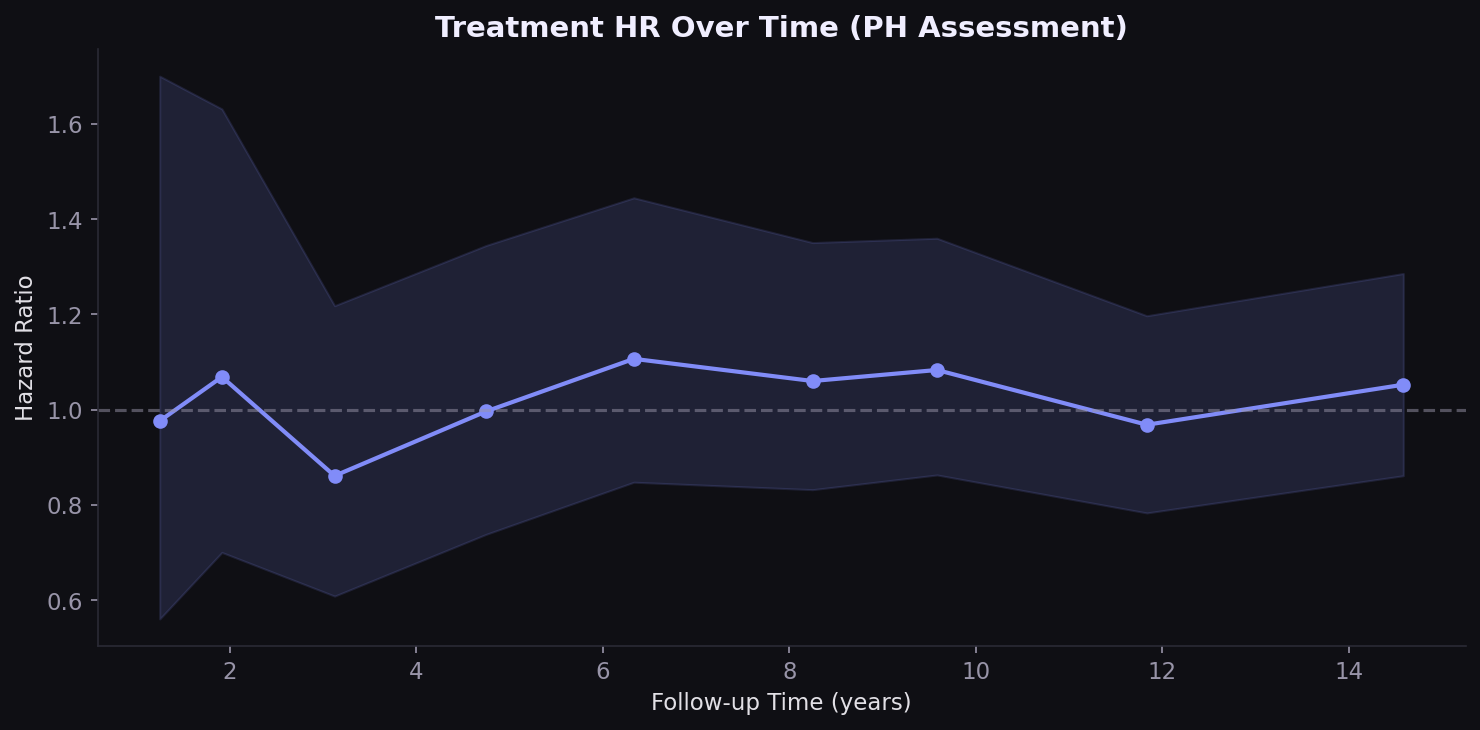

In [7]:
# Schoenfeld residual plot for treatment variable
fig, ax = plt.subplots(figsize=(10, 5))

cph_simple = CoxPHFitter()
cph_simple.fit(matched[['follow_up_yrs', 'cv_death', 'treated']],
               duration_col='follow_up_yrs', event_col='cv_death')

# Manual Schoenfeld-like: plot HR over time using rolling windows
time_cuts = np.quantile(matched.loc[matched['cv_death']==1, 'follow_up_yrs'], np.linspace(0.1, 0.9, 9))
hrs_over_time = []
for t_cut in time_cuts:
    sub = matched[matched['follow_up_yrs'] <= t_cut].copy()
    if sub['cv_death'].sum() >= 10:
        cph_t = CoxPHFitter()
        cph_t.fit(sub[['follow_up_yrs', 'cv_death', 'treated']],
                  duration_col='follow_up_yrs', event_col='cv_death')
        hr_t = np.exp(cph_t.params_['treated'])
        ci_t = np.exp(cph_t.confidence_intervals_.loc['treated'])
        hrs_over_time.append({'time': t_cut, 'HR': hr_t, 'CI_low': ci_t.iloc[0], 'CI_high': ci_t.iloc[1]})

hr_time = pd.DataFrame(hrs_over_time)
ax.plot(hr_time['time'], hr_time['HR'], color=INDIGO, linewidth=2, marker='o', markersize=6)
ax.fill_between(hr_time['time'], hr_time['CI_low'], hr_time['CI_high'], color=INDIGO, alpha=0.15)
ax.axhline(y=1, color='#9894A8', linestyle='--', alpha=0.5)
ax.set_xlabel('Follow-up Time (years)')
ax.set_ylabel('Hazard Ratio')
ax.set_title('Treatment HR Over Time (PH Assessment)', fontsize=14, fontweight='bold', color='#F0EEFF')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'ph_test_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Subgroup analysis: forest plot

In [8]:
def subgroup_hr(data, mask, label):
    sub = data[mask].copy()
    if sub['cv_death'].sum() < 10 or sub['treated'].nunique() < 2:
        return None
    cph = CoxPHFitter()
    cph.fit(sub[['follow_up_yrs', 'cv_death', 'treated']],
            duration_col='follow_up_yrs', event_col='cv_death')
    hr = np.exp(cph.params_['treated'])
    ci = np.exp(cph.confidence_intervals_.loc['treated'])
    p = cph.summary.loc['treated', 'p']
    return {'Subgroup': label, 'HR': hr, 'CI_low': ci.iloc[0], 'CI_high': ci.iloc[1],
            'p': p, 'N': len(sub), 'Events': sub.cv_death.sum()}

subgroups = [
    subgroup_hr(matched, matched['age'] < 65, 'Age < 65'),
    subgroup_hr(matched, matched['age'] >= 65, 'Age >= 65'),
    subgroup_hr(matched, matched['female'] == 0, 'Male'),
    subgroup_hr(matched, matched['female'] == 1, 'Female'),
    subgroup_hr(matched, matched['diabetes'] == 0, 'No Diabetes'),
    subgroup_hr(matched, matched['diabetes'] == 1, 'Diabetes'),
    subgroup_hr(matched, matched['smoker'] == 0, 'Non-Smoker'),
    subgroup_hr(matched, matched['smoker'] == 1, 'Smoker'),
]
subgroups = [s for s in subgroups if s is not None]
sub_df = pd.DataFrame(subgroups)
sub_df

,Subgroup,HR,CI_low,CI_high,p,N,Events
0,Age < 65,1.747519,1.273298,2.398356,0.000549,5261,163
1,Age >= 65,0.990740,0.777653,1.262215,0.939980,1701,263
2,Male,1.203021,0.939993,1.539648,0.142006,3472,254
3,Female,1.294262,0.958086,1.748398,0.092776,3490,172
4,No Diabetes,1.245237,1.004108,1.544272,0.045793,5975,334
5,Diabetes,1.130192,0.748348,1.706872,0.560680,987,92
6,Non-Smoker,1.223034,0.910571,1.642720,0.181035,3325,178
7,Smoker,1.252174,0.975103,1.607973,0.078005,3637,248


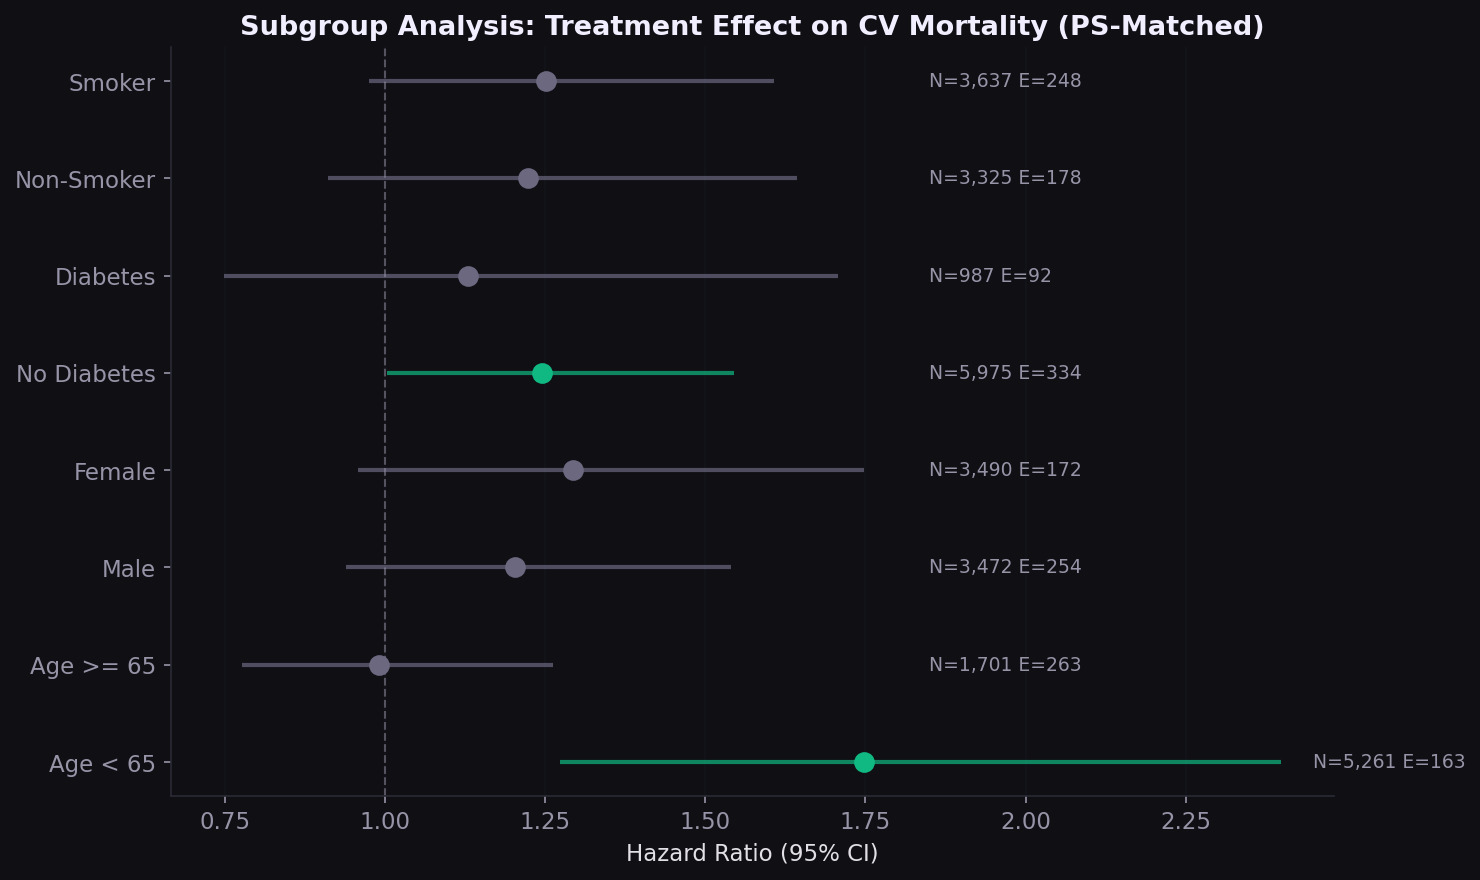

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(sub_df))

for i, (_, row) in enumerate(sub_df.iterrows()):
    color = GREEN if row['p'] < 0.05 else '#6B6880'
    ax.scatter(row['HR'], i, color=color, s=80, zorder=3)
    ax.hlines(i, row['CI_low'], row['CI_high'], color=color, linewidth=2, alpha=0.7)
    ax.text(max(row['CI_high'], 1.8) + 0.05, i,
            f"N={row['N']:,} E={row['Events']}", va='center', fontsize=9, color='#9894A8')

ax.axvline(x=1, color='#9894A8', linestyle='--', alpha=0.5, linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(sub_df['Subgroup'], fontsize=11)
ax.set_xlabel('Hazard Ratio (95% CI)')
ax.set_title('Subgroup Analysis: Treatment Effect on CV Mortality (PS-Matched)',
             fontsize=13, fontweight='bold', color='#F0EEFF')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'subgroup_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary
| Figure | File |
|--------|------|
| KM curves (unadjusted + matched) | `km_curves.png` |
| HR forest plot across methods | `hr_forest_plot.png` |
| PH assumption over time | `ph_test_plot.png` |
| Subgroup forest plot | `subgroup_forest_plot.png` |
| PS distribution (from NB02) | `ps_distribution.png` |
| Love plot (from NB02) | `love_plot.png` |